In [154]:
from scipy.io import loadmat , whosmat
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

path=r"C:\Users\johan\Documents\Documents\School\EDA_course\leukemia.mat"

print(whosmat(path))
data = loadmat(path,simplify_cells=True)
raw_data= {k:v for k,v in data.items() if not k.startswith("__")}
cancer=raw_data["geneinfo"]



[('geneinfo', (51, 2), 'cell'), ('cancertype', (72, 1), 'cell'), ('btcell', (72, 1), 'cell'), ('leukemia', (50, 72), 'double')]


In [218]:
gene_info=np.array(raw_data['geneinfo'])
cancer_type=np.array(raw_data['cancertype'])
btcell=np.array(raw_data['btcell'])
leukemia=np.array(raw_data['leukemia'])

#add feature names and idx to leukemia matrix
index=0
sample_idx=[index+i for i in range(leukemia.shape[1])]
features=[f"G{i+1}" for i in range(leukemia.shape[0])]
#convert to df leukemia
leukemia_df=pd.DataFrame(leukemia, index=features,columns=sample_idx)

#transpose leukemia
leukemia_df_T=leukemia_df.T


#add feature name and idx to geneinfo
gene_info_df_raw=pd.DataFrame(gene_info)
gene_info_df=gene_info_df_raw.drop(index=0).reset_index(drop=True) #reset index
gene_info_df=gene_info_df.rename(columns={0:"Gene Description", 1:"Gene Accession Number"}) #change column names {}

#add feature name and idx to cancertype
cancer_type_df=pd.DataFrame(cancer_type,columns=["cancertype"])
cancer_type_df
#add feature name and idx to btcell
btcell_df=pd.DataFrame(btcell,columns=["btcell"])
gene_info_df






,Gene Description,Gene Accession Number
0,"C-myb gene extracted from Human (c-myb) gene, ...",U22376_cds2_s_at
1,PROTEASOME IOTA CHAIN,X59417_at
2,MB-1 gene,U05259_rna1_at
3,CCND3 Cyclin D3,M92287_at
4,MYL1 Myosin light chain (alkali),M31211_s_at
5,RETINOBLASTOMA BINDING PROTEIN P48,X74262_at
6,Transcriptional activator hSNF2b,D26156_s_at
7,HKR-T1,S50223_at
8,TCF3 Transcription factor 3 (E2A immunoglobuli...,M31523_at
9,Inducible protein mRNA,L47738_at


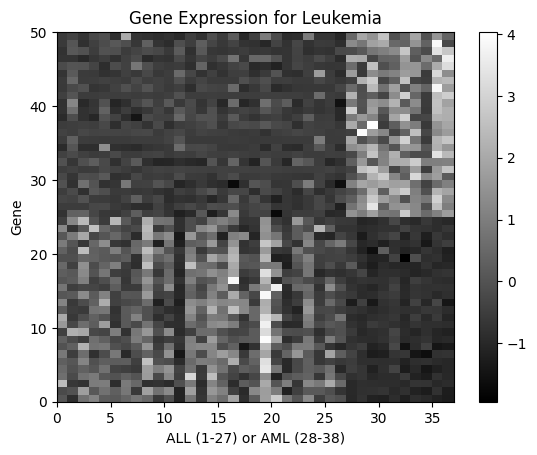

In [169]:
leukemia_copy=leukemia_df_T[0:37]

standarized=leukemia_copy.apply(sc.stats.zscore, axis=0)
plt.pcolor(standarized.T, cmap="gray")
plt.colorbar()
plt.title('Gene Expression for Leukemia')
plt.xlabel('ALL (1-27) or AML (28-38)')
plt.ylabel('Gene')
plt.show()



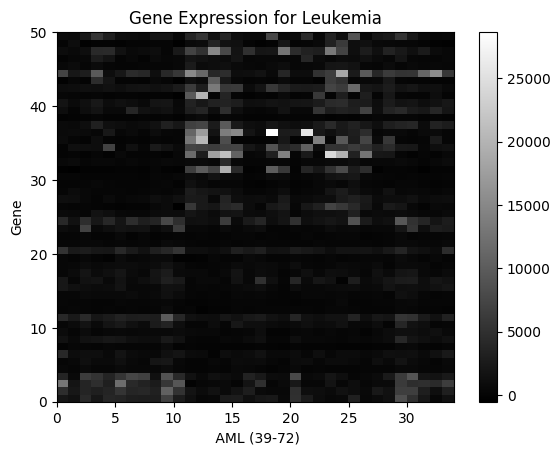

In [170]:
#get the rest of the leukemia samples and check ifthey follow the same pattern
leukemia_39_72=leukemia_df_T[38:]
leukemia_39_72.apply(sc.stats.zscore, axis=0)
plt.pcolor(leukemia_39_72.T, cmap="gray")
plt.colorbar()
plt.title('Gene Expression for Leukemia')
plt.xlabel(' AML (39-72)')
plt.ylabel('Gene')
plt.show()


### lungB dataset


In [210]:
path2= r'C:\Users\johan\Documents\Documents\School\EDA_course\lungB.mat'
lungB_data_raw=loadmat(path2)
lungB_data_raw
print(whosmat(path2))
lungB_data_raw['lungB']

#convert to nparray
labB_np=np.array(lungB_data_raw['labB'])
lungB_np=np.array(lungB_data_raw['lungB'])

#construct index list and feature list
feature_idx=[f"G{i+1}" for i in range(lungB_np.shape[0])]
sample_idx=[i for i in range(lungB_np.shape[1])]
print(len(feature_idx))

#convert from nparray to df
labB_df=pd.DataFrame(labB_np.T,columns=['labB'])
lungB_df=pd.DataFrame(lungB_np.T, index=sample_idx,columns=feature_idx)
lungB_df


[('labB', (1, 156), 'cell'), ('lungB', (675, 156), 'double')]
675


,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G666,G667,G668,G669,G670,G671,G672,G673,G674,G675
0,193.19,2565.55,3361.85,3810.86,2975.29,1158.14,3624.85,867.60,15.40,3828.42,...,56.710,107.010,14.59,317.230,350.78,41.310,700.730,269.020,136.250,0.000
1,369.52,2362.42,3262.46,2616.13,28.23,861.70,2553.35,440.19,62.21,3341.44,...,146.060,310.320,31.42,177.890,145.00,20.800,150.310,184.260,259.510,19.740
2,169.81,1861.83,2967.65,2563.59,41.46,1003.13,2186.26,435.66,17.39,3021.26,...,68.875,533.595,67.47,233.535,505.31,16.370,352.660,153.905,183.985,42.830
3,305.46,2340.89,3473.33,2876.46,2201.87,1006.68,2120.11,470.53,543.77,3004.02,...,397.170,207.935,9.26,302.845,299.91,22.695,333.215,293.380,149.810,132.565
4,413.63,2317.04,3340.84,3354.31,4.09,1380.59,2648.59,750.58,46.62,3190.31,...,280.920,344.320,122.49,236.580,306.09,25.360,24.350,260.770,186.130,93.170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,212.84,2462.27,3219.49,3298.57,2.45,1038.84,2479.05,493.96,0.00,2272.81,...,134.820,238.940,314.87,347.530,99.32,18.140,48.160,173.780,222.450,18.140
152,246.74,916.89,2440.02,3233.64,119.21,1040.33,1985.43,1883.73,6.92,2132.18,...,94.330,361.040,119.21,121.980,138.58,4.160,51.060,220.810,141.340,203.230
153,161.45,930.33,1609.02,2938.96,64.48,1042.02,2282.87,1607.40,0.00,2447.71,...,68.580,353.070,3.66,266.680,163.91,30.780,108.030,172.130,191.040,30.780
154,154.51,1559.22,2361.19,2858.82,1.00,1072.04,2167.59,646.03,0.00,2057.85,...,79.310,383.780,19.98,152.140,84.85,190.150,17.610,242.460,155.300,40.550


(156, 675)


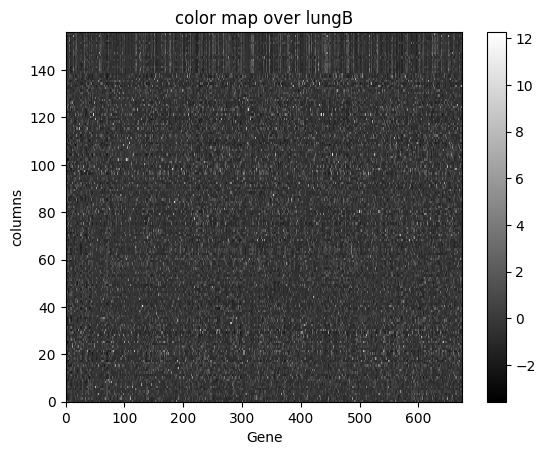

In [217]:
lungB_df_standarized=lungB_df.apply(sc.stats.zscore,axis=0)
print(lungB_df_standarized.shape)
plt.pcolor(lungB_df_standarized,cmap="gray")
plt.colorbar()
plt.xlabel("Gene")
plt.ylabel("columns")
plt.title('color map over lungB')
plt.show()